# Astrometric concordance: Raw vs NN vs PINN

Compares per-source astrometric offsets (band position vs VIS) across three regimes:

1. **Raw WCS** — no correction (classical pipeline positions)
2. **NN predicted** — per-source NN matcher predictions (no field smoothing)
3. **PINN field-corrected** — residuals after subtracting the PINN concordance field

Uses cached predictions from `infer_global_concordance.py --cache-predictions`
and concordance FITS from both grid and PINN solvers (790-tile run with PSF-fit centroids).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
from scipy.interpolate import RegularGridInterpolator

plt.rcParams['figure.dpi'] = 120


def find_repo_root(start: Path = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for cand in [start, *start.parents]:
        if (cand / 'models').exists() and (cand / 'data').exists():
            return cand
    return start


ROOT = find_repo_root()

# ── Paths ────────────────────────────────────────────────────────────────
CACHE_PATH = ROOT / 'models' / 'checkpoints' / 'astro_v7_psffit_all' / 'predictions_cache_790.npz'
FITS_GRID  = ROOT / 'models' / 'checkpoints' / 'astro_v7_psffit_all' / 'concordance_790tiles.fits'
FITS_PINN  = ROOT / 'models' / 'checkpoints' / 'astro_v7_psffit_all' / 'concordance_790tiles_pinn.fits'

for p, label in [(CACHE_PATH, 'Cache'), (FITS_GRID, 'Grid FITS'), (FITS_PINN, 'PINN FITS')]:
    print(f'{label}: {p.name}  {"OK" if p.exists() else "MISSING"}')

RUBIN_BANDS = ['u', 'g', 'r', 'i', 'z', 'y']
NISP_BANDS  = ['Y', 'J', 'H']
ALL_BANDS   = RUBIN_BANDS + NISP_BANDS

def _cache_key(bname):
    return f'nisp_{bname}' if bname in NISP_BANDS else bname

def _fits_ext(bname):
    """FITS extension name prefix for a band."""
    return f'NISP_{bname}' if bname in NISP_BANDS else bname.upper()

Cache: predictions_cache_790.npz  OK
Grid FITS: concordance_790tiles.fits  OK
PINN FITS: concordance_790tiles_pinn.fits  OK


## 1. Load predictions + concordance fields

In [2]:
cache = np.load(str(CACHE_PATH), allow_pickle=True)

# ── Helper: sample the concordance field at source sky positions ──────
def sample_field_at_sources(fits_path, band_name, ra, dec):
    """Interpolate the concordance field (dRA, dDec) at source positions."""
    ext = _fits_ext(band_name)
    with fits.open(fits_path) as hdul:
        try:
            dra_hdu = hdul[f'{ext}.DRA']
            dde_hdu = hdul[f'{ext}.DDE']
        except KeyError:
            return None, None
        dra_map = np.array(dra_hdu.data, dtype=np.float64)
        dde_map = np.array(dde_hdu.data, dtype=np.float64)
        w = WCS(dra_hdu.header)

    # Convert sky coords to pixel coords in the mesh
    px, py = w.wcs_world2pix(ra, dec, 0)
    H, W = dra_map.shape
    # Bilinear interpolation
    y_ax = np.arange(H, dtype=np.float64)
    x_ax = np.arange(W, dtype=np.float64)
    interp_dra = RegularGridInterpolator((y_ax, x_ax), dra_map,
                                          bounds_error=False, fill_value=0.0)
    interp_dde = RegularGridInterpolator((y_ax, x_ax), dde_map,
                                          bounds_error=False, fill_value=0.0)
    pts = np.stack([py, px], axis=-1)
    return interp_dra(pts), interp_dde(pts)


# ── Load per-band data ───────────────────────────────────────────────
data = {}
for bname in ALL_BANDS:
    key = _cache_key(bname)
    if f'{key}_ra' not in cache:
        continue
    ra  = cache[f'{key}_ra']
    dec = cache[f'{key}_dec']
    raw  = cache[f'{key}_raw']  * 1000.0   # arcsec -> mas
    pred = cache[f'{key}_pred'] * 1000.0
    sigma = cache[f'{key}_sigma'] * 1000.0

    # Grid field correction at source positions
    grid_dra, grid_dde = sample_field_at_sources(FITS_GRID, bname, ra, dec)
    # PINN field correction at source positions
    pinn_dra, pinn_dde = sample_field_at_sources(FITS_PINN, bname, ra, dec)

    entry = {
        'ra': ra, 'dec': dec,
        'raw': raw,
        'nn_pred': pred,
        'nn_resid': raw - pred,
        'sigma': sigma,
        'n': len(ra),
    }
    if grid_dra is not None:
        grid_corr = np.stack([grid_dra, grid_dde], axis=1) * 1000.0  # arcsec -> mas
        entry['grid_resid'] = raw - grid_corr
    if pinn_dra is not None:
        pinn_corr = np.stack([pinn_dra, pinn_dde], axis=1) * 1000.0
        entry['pinn_resid'] = raw - pinn_corr

    data[bname] = entry

    prefix = 'NISP ' if bname in NISP_BANDS else 'Rubin '
    raw_med = np.median(np.hypot(raw[:, 0], raw[:, 1]))
    nn_med  = np.median(np.hypot(pred[:, 0], pred[:, 1]))
    grid_med = np.median(np.hypot(entry['grid_resid'][:, 0], entry['grid_resid'][:, 1])) if 'grid_resid' in entry else float('nan')
    pinn_med = np.median(np.hypot(entry['pinn_resid'][:, 0], entry['pinn_resid'][:, 1])) if 'pinn_resid' in entry else float('nan')
    print(f'{prefix}{bname:>2}: {entry["n"]:>7} srcs | '
          f'Raw={raw_med:>5.1f} | NN={nn_med:>5.1f} | Grid={grid_med:>5.1f} | PINN={pinn_med:>5.1f} mas')

Rubin  u:   76084 srcs | Raw= 71.8 | NN=  5.5 | Grid= 71.9 | PINN= 71.8 mas
Rubin  g:   98924 srcs | Raw= 58.9 | NN= 50.6 | Grid= 59.7 | PINN= 58.9 mas
Rubin  r:  105739 srcs | Raw= 53.8 | NN= 45.8 | Grid= 54.2 | PINN= 53.4 mas
Rubin  i:  104292 srcs | Raw= 53.2 | NN= 43.5 | Grid= 54.1 | PINN= 53.1 mas
Rubin  z:   96067 srcs | Raw= 58.6 | NN= 48.1 | Grid= 59.6 | PINN= 58.5 mas
Rubin  y:   81360 srcs | Raw= 67.8 | NN=  6.3 | Grid= 68.2 | PINN= 67.9 mas
NISP  Y:  126769 srcs | Raw= 42.8 | NN= 17.4 | Grid= 43.0 | PINN= 42.6 mas
NISP  J:  128853 srcs | Raw= 41.2 | NN= 17.5 | Grid= 41.1 | PINN= 40.7 mas
NISP  H:  127493 srcs | Raw= 42.5 | NN= 18.4 | Grid= 42.5 | PINN= 42.2 mas


## 2. Bar chart: Raw vs NN vs Grid vs PINN per band

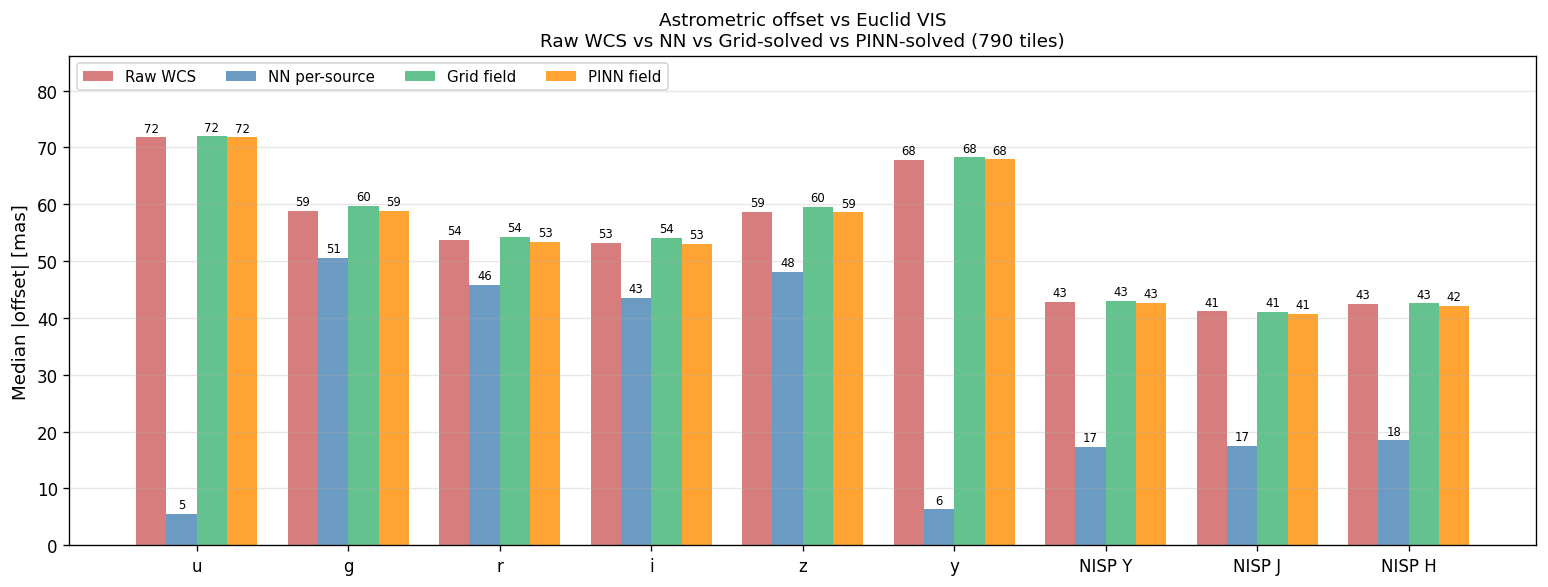


      Band       N     Raw     NN   Grid   PINN   Grid %  PINN %
----------------------------------------------------------------------
    u   76084   71.8    5.5   71.9   71.8    -0.2%    -0.0%
    g   98924   58.9   50.6   59.7   58.9    -1.4%    +0.1%
    r  105739   53.8   45.8   54.2   53.4    -0.8%    +0.7%
    i  104292   53.2   43.5   54.1   53.1    -1.6%    +0.3%
    z   96067   58.6   48.1   59.6   58.5    -1.7%    +0.1%
    y   81360   67.8    6.3   68.2   67.9    -0.7%    -0.2%
NISP     Y  126769   42.8   17.4   43.0   42.6    -0.5%    +0.3%
NISP     J  128853   41.2   17.5   41.1   40.7    +0.2%    +1.0%
NISP     H  127493   42.5   18.4   42.5   42.2    -0.1%    +0.8%


In [3]:
bands_present = [b for b in ALL_BANDS if b in data]
x = np.arange(len(bands_present))
width = 0.2

raw_med  = [np.median(np.hypot(data[b]['raw'][:, 0], data[b]['raw'][:, 1])) for b in bands_present]
nn_med   = [np.median(np.hypot(data[b]['nn_pred'][:, 0], data[b]['nn_pred'][:, 1])) for b in bands_present]
grid_med = [np.median(np.hypot(data[b]['grid_resid'][:, 0], data[b]['grid_resid'][:, 1]))
            if 'grid_resid' in data[b] else 0 for b in bands_present]
pinn_med = [np.median(np.hypot(data[b]['pinn_resid'][:, 0], data[b]['pinn_resid'][:, 1]))
            if 'pinn_resid' in data[b] else 0 for b in bands_present]

fig, ax = plt.subplots(figsize=(13, 5))
bars0 = ax.bar(x - 1.5*width, raw_med,  width, label='Raw WCS',       color='indianred',  alpha=0.8)
bars1 = ax.bar(x - 0.5*width, nn_med,   width, label='NN per-source',  color='steelblue',  alpha=0.8)
bars2 = ax.bar(x + 0.5*width, grid_med, width, label='Grid field',     color='mediumseagreen', alpha=0.8)
bars3 = ax.bar(x + 1.5*width, pinn_med, width, label='PINN field',     color='darkorange', alpha=0.8)

for bars, vals in [(bars0, raw_med), (bars1, nn_med), (bars2, grid_med), (bars3, pinn_med)]:
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.0f}', ha='center', va='bottom', fontsize=7)

labels = [f'NISP {b}' if b in NISP_BANDS else b for b in bands_present]
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('Median |offset| [mas]', fontsize=11)
ax.set_title('Astrometric offset vs Euclid VIS\nRaw WCS vs NN vs Grid-solved vs PINN-solved (790 tiles)', fontsize=11)
ax.legend(fontsize=9, ncol=4, loc='upper left')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, max(raw_med) * 1.2)
plt.tight_layout()
plt.savefig('astrometry_bar_chart.png', dpi=200, bbox_inches='tight')
plt.show()

# ── Summary table ────────────────────────────────────────────────────────
print(f'\n{"Band":>10} {"N":>7}  {"Raw":>6} {"NN":>6} {"Grid":>6} {"PINN":>6}  {"Grid %":>7} {"PINN %":>7}')
print('-' * 70)
for i, b in enumerate(bands_present):
    prefix = 'NISP ' if b in NISP_BANDS else ''
    g_pct = (1 - grid_med[i] / raw_med[i]) * 100 if raw_med[i] > 0 else 0
    p_pct = (1 - pinn_med[i] / raw_med[i]) * 100 if raw_med[i] > 0 else 0
    print(f'{prefix}{b:>5} {data[b]["n"]:>7}  {raw_med[i]:>5.1f}  {nn_med[i]:>5.1f}  '
          f'{grid_med[i]:>5.1f}  {pinn_med[i]:>5.1f}  {g_pct:>+6.1f}%  {p_pct:>+6.1f}%')

## 3. Histograms: Raw vs Grid vs PINN residuals per band

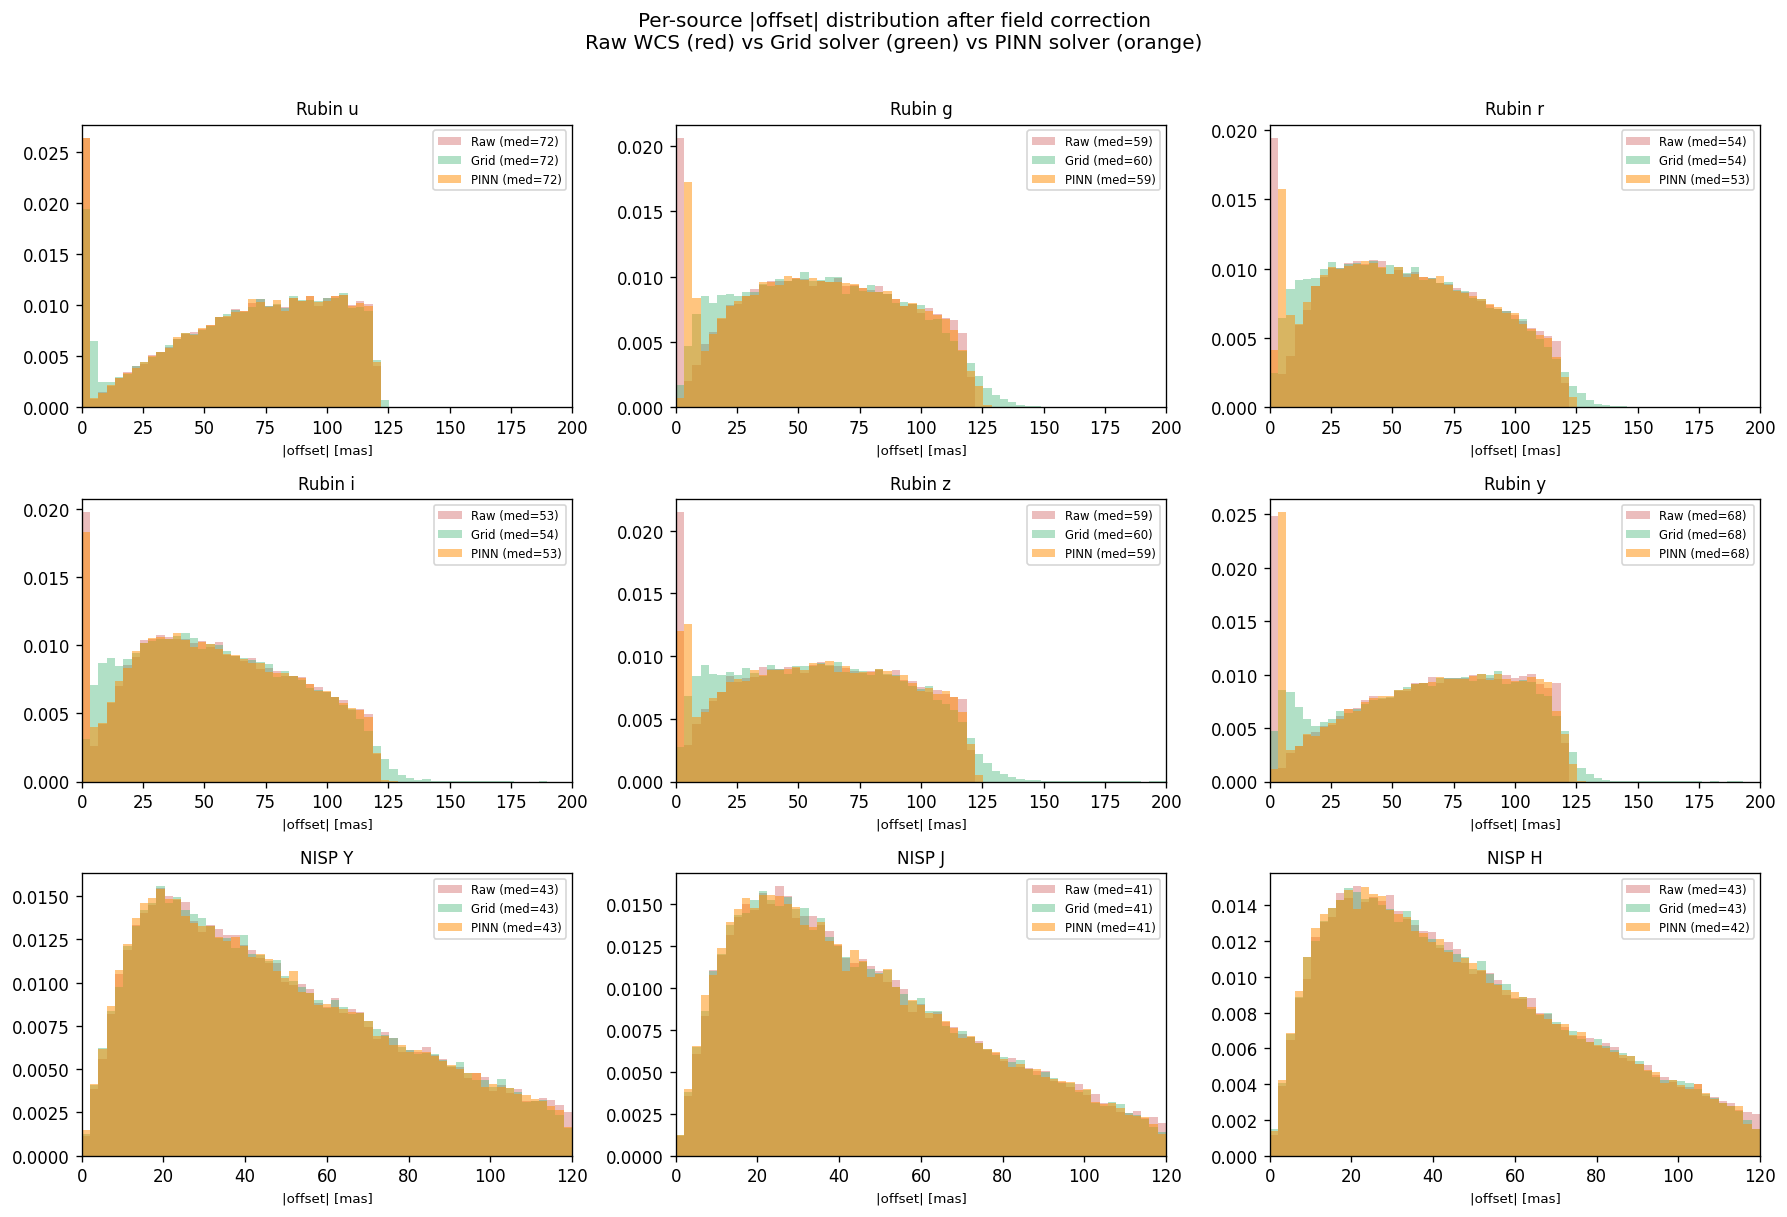

In [4]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes_flat = axes.ravel()

for idx, band in enumerate(bands_present):
    ax = axes_flat[idx]
    d = data[band]
    raw_mag  = np.hypot(d['raw'][:, 0], d['raw'][:, 1])
    
    xlim = 200 if band in RUBIN_BANDS else 120
    bins = np.linspace(0, xlim, 60)
    
    ax.hist(raw_mag, bins=bins, alpha=0.4, color='indianred', density=True,
            label=f'Raw (med={np.median(raw_mag):.0f})')
    
    if 'grid_resid' in d:
        grid_mag = np.hypot(d['grid_resid'][:, 0], d['grid_resid'][:, 1])
        ax.hist(grid_mag, bins=bins, alpha=0.4, color='mediumseagreen', density=True,
                label=f'Grid (med={np.median(grid_mag):.0f})')
    
    if 'pinn_resid' in d:
        pinn_mag = np.hypot(d['pinn_resid'][:, 0], d['pinn_resid'][:, 1])
        ax.hist(pinn_mag, bins=bins, alpha=0.5, color='darkorange', density=True,
                label=f'PINN (med={np.median(pinn_mag):.0f})')
    
    prefix = 'NISP ' if band in NISP_BANDS else 'Rubin '
    ax.set_title(f'{prefix}{band}', fontsize=10)
    ax.set_xlabel('|offset| [mas]', fontsize=8)
    ax.set_xlim(0, xlim)
    ax.legend(fontsize=7)

plt.suptitle('Per-source |offset| distribution after field correction\n'
             'Raw WCS (red) vs Grid solver (green) vs PINN solver (orange)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('astrometry_histograms.png', dpi=200, bbox_inches='tight')
plt.show()

In [5]:
## 4. Decomposed statistics

def _mad_sigma(x):
    return 1.4826 * np.median(np.abs(x - np.median(x)))

print(f'{"Band":>10} {"N":>7}   {"--- Raw WCS ---":^24s}   {"--- Grid resid ---":^24s}   {"--- PINN resid ---":^24s}')
print(f'{"":>10} {"":>7}   {"|sys|":>6} {"med":>6} {"MAD_RA":>6} {"MAD_De":>6}   '
      f'{"|sys|":>6} {"med":>6} {"MAD_RA":>6} {"MAD_De":>6}   '
      f'{"|sys|":>6} {"med":>6} {"MAD_RA":>6} {"MAD_De":>6}')
print('-' * 110)

for bname in bands_present:
    d = data[bname]
    raw = d['raw']
    n = d['n']
    
    def _stats(arr):
        sys = np.hypot(np.median(arr[:, 0]), np.median(arr[:, 1]))
        med = np.median(np.hypot(arr[:, 0], arr[:, 1]))
        mad_ra = _mad_sigma(arr[:, 0])
        mad_de = _mad_sigma(arr[:, 1])
        return sys, med, mad_ra, mad_de
    
    r = _stats(raw)
    g = _stats(d['grid_resid']) if 'grid_resid' in d else (0, 0, 0, 0)
    p = _stats(d['pinn_resid']) if 'pinn_resid' in d else (0, 0, 0, 0)
    
    prefix = 'NISP ' if bname in NISP_BANDS else ''
    print(f'{prefix}{bname:>5} {n:>7}   '
          f'{r[0]:>5.1f}  {r[1]:>5.1f}  {r[2]:>5.1f}  {r[3]:>5.1f}   '
          f'{g[0]:>5.1f}  {g[1]:>5.1f}  {g[2]:>5.1f}  {g[3]:>5.1f}   '
          f'{p[0]:>5.1f}  {p[1]:>5.1f}  {p[2]:>5.1f}  {p[3]:>5.1f}')

print()
print('|sys| = bulk systematic (should drop after correction)')
print('med = median |offset| (total per-source scatter)')
print('MAD = centroid noise per axis (hard floor from measurement noise)')

      Band       N       --- Raw WCS ---           --- Grid resid ---         --- PINN resid ---   
                      |sys|    med MAD_RA MAD_De    |sys|    med MAD_RA MAD_De    |sys|    med MAD_RA MAD_De
--------------------------------------------------------------------------------------------------------------
    u   76084     0.0   71.8   57.2   57.3     1.7   71.9   57.2   57.3     1.8   71.8   57.2   57.3
    g   98924     0.4   58.9   47.1   46.7     5.7   59.7   48.1   47.1     5.9   58.9   47.0   46.7
    r  105739     4.5   53.8   42.1   42.4     4.2   54.2   42.9   43.2     2.9   53.4   42.1   42.4
    i  104292     4.9   53.2   41.9   41.6     6.1   54.1   42.9   42.4     4.1   53.1   41.9   41.6
    z   96067     0.0   58.6   45.9   45.6     1.7   59.6   46.5   46.4     2.4   58.5   45.7   45.6
    y   81360     0.0   67.8   53.8   53.5     3.2   68.2   54.0   54.1     4.3   67.9   53.7   53.6
NISP     Y  126769     6.5   42.8   34.3   34.6     3.7   43.0   34.6   35